In [3]:
import os
import numpy as np
import pandas as pd
import struct
import matplotlib.pyplot as plt
from pathlib import Path
import phonlab as phon
from fileorganize import dir_to_df

## define a function to read Deng et al. 'fb' files

    * return a dataframe

In [2]:
def read_fmt_file(FMTFILE):
    ''' Read an HTK format .fb file in the Deng et al. formants database.
            This code was generated by Claude from the Deng et al. matlab hint.
            
    In struct.unpack() 
        '>i' is a big-endian 4-byte integer
        '>h' is a big-endian 2-byte integer
        '>f' is a big-endian 4-byte float
    '''
    with open(FMTFILE, 'rb') as fid:
        n_frame = struct.unpack('>i', fid.read(4))[0]
        samPeriod = struct.unpack('>i', fid.read(4))[0]
        stepsize = samPeriod * 1e-6  # convert to seconds
        sampSize = struct.unpack('>h', fid.read(2))[0]
        numComps = sampSize // 4
        fileType = struct.unpack('>h', fid.read(2))[0]

        # Initialize data list
        data_list = []
        
        # Read data
        for n in range(n_frame):
            # Read numComps float values
            data = struct.unpack(f'>{numComps}f', fid.read(4 * numComps))
            data_list.append(data)

        # Create DataFrame
        column_names = [[f'F{i+1}' for i in range(numComps//2)] + [f'BW{i+1}' for i in range(numComps//2)]]
        df = pd.DataFrame(data_list, columns=column_names)
        df = (df * 1000).astype(int)  # formants in Hz

        # add time axis
        sec = np.round(np.array([i * stepsize for i in range(n_frame)]) + stepsize/2, 3)
        df.insert(0, 'sec', sec)  # make it the first column

    return df

## Get a list of all of the fb files.

In [3]:
audio_dir = Path('/Volumes') / 'WDBook' / 'Corpora' / 'TIMIT' 

path_to_VTR = Path('.')

list_of_fb_files = dir_to_df(path_to_VTR,
           fnpat = r'\w+\.fb',
           addcols = ["dirname", "barename"])
list_of_fb_files.head()

,dirname,relpath,fname,barename
0,.,test/dr1/felc0,si1386.fb,si1386
1,.,test/dr1/felc0,si2016.fb,si2016
2,.,test/dr1/felc0,si756.fb,si756
3,.,test/dr1/felc0,sx126.fb,sx126
4,.,test/dr1/felc0,sx216.fb,sx216


## Test the main part of the code for making textgrid files.

VTR_phonlab/test/dr1/felc0/si1386.csv
         t1        t2          word
0  0.132500  0.284562            in
1  0.284562  0.748000          wage
2  0.748000  1.840625  negotiations
3  1.865000  1.992125           the
4  1.992125  2.428250      industry


(<Axes: xlabel='Time (sec)', ylabel='Frequency (Hz)'>,
 array([0.00000000e+00, 1.95312500e+00, 3.90625000e+00, ...,
        7.99609375e+03, 7.99804688e+03, 8.00000000e+03]),
 array([0.744, 0.745, 0.746, ..., 1.894, 1.895, 1.896]),
 array([[17.64961879, 17.98534791, 24.1338621 , ...,  9.47635965,
         39.50636436, 22.10845149],
        [17.65100117, 17.98976734, 24.13424535, ...,  9.68830001,
         39.50653867, 22.16265477],
        [17.65514479, 18.00299122, 24.1353945 , ..., 10.25641617,
         39.50706098, 22.32109115],
        ...,
        [19.16228891,  1.04645336,  5.84485172, ..., 34.08071284,
         36.40792936, 35.80457086],
        [19.1597108 ,  0.59347814,  5.80509814, ..., 34.08378457,
         36.409059  , 35.80512136],
        [19.15885071,  0.29667798,  5.7917269 , ..., 34.08480837,
         36.4094356 , 35.80530484]]))

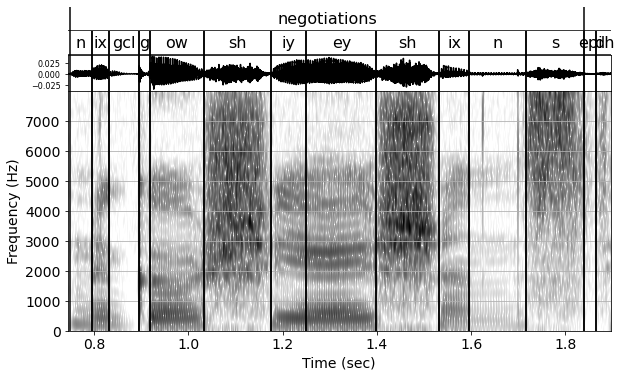

In [4]:
fs = 16000  # assume this for TIMIT

row = list_of_fb_files.iloc[0]

fmt_name = row.dirname / row.relpath / row.fname

new_directory = Path("VTR_phonlab") / row.relpath 
os.makedirs(new_directory, exist_ok = True)

new_barename = new_directory / row.barename

csv_name = new_barename.with_suffix(".csv")

# --- copy the audio file -------
audio_name = (audio_dir / row.relpath / row.barename).with_suffix(".wav")   # read the audio file from here
outwav_name = new_barename.with_suffix(".wav") # copy it to here
os.system(f'cp {audio_name} {outwav_name}')  
# --------

print(csv_name)

df = read_fmt_file(fmt_name)
df.to_csv(csv_name,index=False)

phones_file = fmt_name.with_suffix(".phn")
words_file = fmt_name.with_suffix(".wrd")

phdf = pd.read_csv(phones_file,sep=r'\s+',names=['t1','t2','phone'])  
phdf.t1 = phdf.t1/fs  # convert sample number to seconds
phdf.t2 = phdf.t2/fs
wddf = pd.read_csv(words_file,sep=r'\s+',names=['t1','t2','word'])
wddf.t1 = wddf.t1/fs  # convert sample number to seconds
wddf.t2 = wddf.t2/fs

## ------------------ write the labels out to a textgrid ------------------------
textgrid_name = fmt_name.with_suffix(".TextGrid")
phon.df_to_tg([phdf,wddf],['phone','word'], outfile= textgrid_name) 
## ------------------------------------------------------------------------------

# ----- sanity checking
print(wddf.head())

x,fs = phon.loadsig(audio_name, chansel=[0])

start = 0.74
end = 1.9

height_ratios = [1, 1, 1.5, 10]
fig,[wrd,phn,wav,specgrm] = phon.make_figure(height_ratios)

# fill the figure with textgrid and acoustic data
phon.plot_tier(phdf, start, end, ax=phn, mark_in_plot=[wav,specgrm],span_time=0.5)
phon.plot_tier(wddf, start, end, ax=wrd) # word tier at top
phon.display_wave(x,fs,start, end, ylabel="", font_size=8, ax=wav)
phon.sgram(x,fs,start, end, ax=specgrm)


## Here is the loop to process all of the files

- this creates a new version of the VTR corpus
- fb files are writen as .csv text files
- phn and wrd files are converted to a two-tiered Praat TextGrid
- the directory structure of the original corpus is maintained
- audio wav files are added to the corpus

In [5]:
fs = 16000
audio_dir = Path('/Volumes') / 'WDBook' / 'Corpora' / 'TIMIT' 

old_relpath = ""
for row in list_of_fb_files.itertuples():
    if row.relpath != old_relpath:
        old_relpath = row.relpath
        print(row.relpath)

        new_directory = Path("VTR_phonlab") / row.relpath 
        os.makedirs(new_directory, exist_ok = True)

    # destination file names
    new_barename = new_directory / row.barename
    csv_name = new_barename.with_suffix(".csv")
    textgrid_name = new_barename.with_suffix(".TextGrid")
    outwav_name = new_barename.with_suffix(".wav")


    # source filenames 
    fmt_name = row.dirname / row.relpath / row.fname
    phones_file = fmt_name.with_suffix(".phn")
    words_file = fmt_name.with_suffix(".wrd")
    audio_name = (audio_dir / row.relpath / row.barename).with_suffix(".wav")   # read the audio file from here

    ## ------ copy the audio file --------------------
    os.system(f'cp {audio_name} {outwav_name}')  
    ## ---------------------------------------------
    
    ## ----------- read the formants file, write it as a csv  --------------
    df = read_fmt_file(fmt_name)  # read the .fmt binary file
    df.to_csv(csv_name,index=False) # write it as a .csv text file
    ## ---------------------------------------------------------------------

    ## -------- read the phones and words files -----------------------------
    phdf = pd.read_csv(phones_file,sep=r'\s+',names=['t1','t2','phone'])  
    phdf.t1 = phdf.t1/fs  # convert sample number to seconds
    phdf.t2 = phdf.t2/fs
    wddf = pd.read_csv(words_file,sep=r'\s+',names=['t1','t2','word'])
    wddf.t1 = wddf.t1/fs  # convert sample number to seconds
    wddf.t2 = wddf.t2/fs
    ## -------------------------------------------------------------------------

    ## ------ deal with cases where a segment is shared across a word boundary ------
    i = wddf.t2.shift(1)
    j = wddf.t1

    # cases where prior word ends after current word starts 
    for idx in wddf.loc[i-j>0].index.to_list(): 
        end = wddf.iloc[idx-1].t2  # end of shared segment
        begin = wddf.iloc[idx].t1  # beginning of shared segment
        mid = (begin+end)/2
        wddf.loc[idx-1,"t2"] = mid # split the shared segment between the words
        wddf.loc[idx,"t1"] = mid
    ## -----------------------------------------------------------------------------
    
    ## ------------------ write the labels out to a textgrid --------------------
    phon.df_to_tg([phdf,wddf],['phone','word'], outfile= textgrid_name) 
    ## --------------------------------------------------------------------------



test/dr1/felc0
test/dr1/mdab0
test/dr1/mwbt0
test/dr2/fpas0
test/dr2/mtas1
test/dr2/mwew0
test/dr3/fpkt0
test/dr3/mjmp0
test/dr3/mlnt0
test/dr4/fjlm0
test/dr4/mlll0
test/dr4/mtls0
test/dr5/fnlp0
test/dr5/mbpm0
test/dr5/mklt0
test/dr6/fmgd0
test/dr6/mcmj0
test/dr6/mjdh0
test/dr7/fdhc0
test/dr7/mgrt0
test/dr7/mnjm0
test/dr8/fmld0
test/dr8/mjln0
test/dr8/mpam0
train/dr1/fcjf0
train/dr1/fdaw0
train/dr1/fdml0
train/dr1/fecd0
train/dr1/fetb0
train/dr1/fjsp0
train/dr1/fkfb0
train/dr1/fmem0
train/dr1/fsah0
train/dr1/fsjk1
train/dr1/fsma0
train/dr1/ftbr0
train/dr1/fvfb0
train/dr1/fvmh0
train/dr1/mcpm0
train/dr1/mdac0
train/dr1/mdpk0
train/dr1/medr0
train/dr1/mgrl0
train/dr1/mjeb1
train/dr1/mjwt0
train/dr1/mkls0
train/dr1/mklw0
train/dr3/falk0
train/dr3/fcke0
train/dr3/madc0
train/dr3/makb0
train/dr3/makr0
train/dr3/mapv0
train/dr3/mbef0
train/dr3/mcal0
train/dr3/mcdc0
train/dr3/mcdd0
train/dr3/mcef0
train/dr3/mdbb1
train/dr3/mddc0
train/dr3/mdef0
train/dr3/mdhs0
train/dr3/mdjm0
train/dr3/mdlc0
